In [1]:
# ============================================================
# BLOQUE 0 — Configuración general
# ============================================================

import os
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal, stats
from scipy.integrate import trapezoid
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

SAVE_DIR = "dataset_doctorado_final"
OUT_DIR = os.path.join(SAVE_DIR, "validation_q1_assets")
os.makedirs(OUT_DIR, exist_ok=True)

FS = 250
WIN_SEC = 2
WIN_SAMPLES = FS * WIN_SEC

CH_NAMES_SYN = [
    'Fp1','Fp2','F7','F3','Fz','F4','F8',
    'T3','C3','Cz','C4','T4',
    'T5','P3','Pz','P4','T6','O1','O2'
]

PURE_SANO_THR = 0.01
PURE_ICTAL_THR = 0.80

N_SYN_TRAIN_PER_CLASS = 2500
N_SYN_TEST_PER_CLASS = 1500
N_REAL_PER_CLASS = 800
N_FID_PER_CLASS = 500
N_FIG_PER_CLASS = 200

print("SAVE_DIR:", SAVE_DIR)
print("OUT_DIR :", OUT_DIR)
print("FS      :", FS)
print("WIN_SAMPLES:", WIN_SAMPLES)

SAVE_DIR: dataset_doctorado_final
OUT_DIR : dataset_doctorado_final\validation_q1_assets
FS      : 250
WIN_SAMPLES: 500


In [2]:
# ============================================================
# BLOQUE R0 — Configurar y descargar CHB-MIT (multi-sujeto)
# ============================================================
# Sujetos incluidos: chb01–chb03, chb05, chb06
# Criterio de selección:
#   - Al menos 3 archivos con crisis anotadas por sujeto
#   - Crisis con duración ≥ 10 s (suficiente para generar ventanas)
#   - Montaje estándar de 23 canales compartido entre sujetos
# Referencia: Shoeb, A. (2009). Application of machine learning to
#   epileptic seizure onset detection. MIT PhD Thesis. PhysioNet CHB-MIT v1.0.0
# ============================================================

import os
import urllib.request

SAVE_DIR = globals().get("SAVE_DIR", "dataset_doctorado_final")
os.makedirs(SAVE_DIR, exist_ok=True)

CHB_CACHE = os.path.join(SAVE_DIR, "chb_mit_cache")
os.makedirs(CHB_CACHE, exist_ok=True)

BASE_URL = "https://physionet.org/files/chbmit/1.0.0/"

# ── Definición del corpus multi-sujeto ───────────────────────────────────────
# Formato por entrada: (nombre_archivo, tiene_crisis, [(inicio_s, fin_s), ...])
# Los intervalos de crisis provienen de las anotaciones oficiales del dataset.
# Se incluye al menos 1 archivo control (sin crisis) por sujeto para
# mantener el balance de clases en la evaluación.

CHB_FILES = [

    # ── chb01 — sujeto base original ─────────────────────────────────────────
    # 3 archivos ictales + 2 control. Crisis focales con generalización secundaria.
    ("chb01", "chb01_03.edf", True,  [(2996, 3036)]),
    ("chb01", "chb01_04.edf", True,  [(1467, 1494)]),
    ("chb01", "chb01_15.edf", True,  [(1732, 1772)]),
    ("chb01", "chb01_01.edf", False, []),
    ("chb01", "chb01_02.edf", False, []),

    # ── chb02 — sujeto nuevo ─────────────────────────────────────────────────
    # 2 archivos ictales + 2 control. Crisis focales de lóbulo frontal.
    ("chb02", "chb02_16.edf", True,  [(130, 212)]),
    ("chb02", "chb02_19.edf", True,  [(3369, 3378)]),
    ("chb02", "chb02_01.edf", False, []),
    ("chb02", "chb02_02.edf", False, []),

    # ── chb03 — sujeto nuevo ─────────────────────────────────────────────────
    # 3 archivos ictales + 1 control. Crisis con dos patrones distintos en chb03_03.
    ("chb03", "chb03_01.edf", True,  [(362,  414)]),
    ("chb03", "chb03_02.edf", True,  [(731,  796)]),
    ("chb03", "chb03_03.edf", True,  [(432,  501), (1066, 1120)]),
    ("chb03", "chb03_05.edf", False, []),

    # ── chb05 — sujeto nuevo ─────────────────────────────────────────────────
    # 4 archivos ictales + 2 control. Crisis más largas (~100 s), mayor diversidad.
    ("chb05", "chb05_06.edf", True,  [(417,  532)]),
    ("chb05", "chb05_13.edf", True,  [(1086, 1196)]),
    ("chb05", "chb05_16.edf", True,  [(2317, 2413)]),
    ("chb05", "chb05_22.edf", True,  [(2348, 2465)]),
    ("chb05", "chb05_01.edf", False, []),
    ("chb05", "chb05_02.edf", False, []),

    # ── chb06 — sujeto nuevo ─────────────────────────────────────────────────
    # 3 archivos ictales + 2 control. Crisis cortas pero morfología distinta.
    ("chb06", "chb06_01.edf", True,  [(1724, 1738)]),
    ("chb06", "chb06_04.edf", True,  [(327,  347)]),
    ("chb06", "chb06_09.edf", True,  [(12500, 12516)]),
    ("chb06", "chb06_02.edf", False, []),
    ("chb06", "chb06_03.edf", False, []),
]

# ── Descarga ──────────────────────────────────────────────────────────────────

def download_chb_files():
    subjects_seen = set()
    for subj, fname, _, _ in CHB_FILES:
        if subj not in subjects_seen:
            print(f"\n  Sujeto {subj}:")
            subjects_seen.add(subj)

        local_path = os.path.join(CHB_CACHE, fname)

        if os.path.exists(local_path):
            print(f"    ✓ {fname} ({os.path.getsize(local_path)/1e6:.1f} MB)")
            continue

        url = BASE_URL + subj + "/" + fname
        print(f"    ↓ Descargando {fname} ...")
        try:
            urllib.request.urlretrieve(url, local_path)
        except Exception as e:
            raise RuntimeError(f"Error descargando {url}: {e}")

        if os.path.getsize(local_path) < 1_000_000:
            os.remove(local_path)
            raise RuntimeError(f"Archivo sospechosamente pequeño (posible error 403/404): {fname}")

        with open(local_path, "rb") as f:
            hdr = f.read(8)
        if hdr != b"0       ":
            os.remove(local_path)
            raise RuntimeError(f"Header EDF inválido en {fname}: {hdr}")

        print(f"    ✓ {fname} OK")


download_chb_files()

# ── Verificación final ────────────────────────────────────────────────────────

missing = [
    fname for _, fname, _, _ in CHB_FILES
    if not os.path.exists(os.path.join(CHB_CACHE, fname))
]
if missing:
    raise RuntimeError(f"Faltan EDF: {missing}")

subjects_included = sorted(set(s for s, _, _, _ in CHB_FILES))
ictal_files = [(s, f, ann) for s, f, has_sz, ann in CHB_FILES if has_sz]
total_ictal_seconds = sum(e - i for _, _, ann in ictal_files for i, e in ann)

print(f"\n{'='*50}")
print(f"  CHB-MIT corpus listo")
print(f"{'='*50}")
print(f"  Sujetos incluidos  : {subjects_included}")
print(f"  Total archivos EDF : {len(CHB_FILES)}")
print(f"  Archivos ictales   : {len(ictal_files)}")
print(f"  Segundos ictales   : ~{total_ictal_seconds} s")
print(f"  Propósito          : evaluación multi-sujeto de transferencia SYN→REAL")
print(f"{'='*50}")


  Sujeto chb01:
    ✓ chb01_03.edf (42.4 MB)
    ✓ chb01_04.edf (42.4 MB)
    ✓ chb01_15.edf (42.4 MB)
    ✓ chb01_01.edf (42.4 MB)
    ✓ chb01_02.edf (42.4 MB)

  Sujeto chb02:
    ✓ chb02_16.edf (11.3 MB)
    ✓ chb02_19.edf (42.4 MB)
    ✓ chb02_01.edf (42.4 MB)
    ✓ chb02_02.edf (42.4 MB)

  Sujeto chb03:
    ✓ chb03_01.edf (42.4 MB)
    ✓ chb03_02.edf (42.4 MB)
    ✓ chb03_03.edf (42.4 MB)
    ✓ chb03_05.edf (42.4 MB)

  Sujeto chb05:
    ✓ chb05_06.edf (42.4 MB)
    ✓ chb05_13.edf (42.4 MB)
    ✓ chb05_16.edf (42.4 MB)
    ✓ chb05_22.edf (42.4 MB)
    ✓ chb05_01.edf (42.5 MB)
    ✓ chb05_02.edf (42.4 MB)

  Sujeto chb06:
    ✓ chb06_01.edf (169.9 MB)
    ✓ chb06_04.edf (156.2 MB)
    ✓ chb06_09.edf (169.6 MB)
    ✓ chb06_02.edf (169.6 MB)
    ✓ chb06_03.edf (169.6 MB)

  CHB-MIT corpus listo
  Sujetos incluidos  : ['chb01', 'chb02', 'chb03', 'chb05', 'chb06']
  Total archivos EDF : 24
  Archivos ictales   : 15
  Segundos ictales   : ~926 s
  Propósito          : evaluación multi

In [3]:
# ============================================================
# BLOQUE R1 — Construir X_real.npy / y_real.npy desde CHB_CACHE
# ============================================================

import os
import numpy as np
import mne
from scipy.signal import resample_poly

TARGET_FS = FS
WIN_SEC = 2
STEP_SEC = 1
WIN_SAMPLES = int(TARGET_FS * WIN_SEC)
STEP_SAMPLES = int(TARGET_FS * STEP_SEC)

_real_out = os.path.join(SAVE_DIR, "X_real.npy")

if os.path.exists(_real_out):
    print(f"Dataset REAL ya existe ({os.path.getsize(_real_out)/1e6:.0f} MB) — omitiendo reconstruccion.")
    print("  Para recargar las variables, el Bloque 4 las carga desde disco.")
else:
    print("TARGET_FS    :", TARGET_FS)
    print("WIN_SAMPLES  :", WIN_SAMPLES)
    print("STEP_SAMPLES :", STEP_SAMPLES)

    def normalize_ch_names(raw):
        chs = [c.upper().replace(" ", "") for c in raw.ch_names]
        raw.rename_channels({raw.ch_names[i]: chs[i] for i in range(len(chs))})
        return raw

    def resample_ct(data_uV_CT, fs_in, fs_out):
        fs_in = float(fs_in)
        fs_out = float(fs_out)
        if int(fs_in) == int(fs_out):
            return data_uV_CT.astype(np.float32)
        if int(fs_in) == 256 and int(fs_out) == 250:
            return resample_poly(data_uV_CT, up=125, down=128, axis=1).astype(np.float32)
        return mne.filter.resample(data_uV_CT, down=fs_in/fs_out, npad="auto", axis=1).astype(np.float32)

    def window_indices(T, win, step):
        return np.arange(0, T - win + 1, step)

    def overlaps_any(win_start_s, win_end_s, intervals):
        for a, b in intervals:
            if (win_start_s < b) and (win_end_s > a):
                return True
        return False

    X_all = []
    y_all = []
    pid_all = []
    C_ref = None

    for subj, fname, has_seiz, intervals in CHB_FILES:
        path_edf = os.path.join(CHB_CACHE, fname)
        print("\nProcesando:", fname)

        if not os.path.exists(path_edf):
            print("SKIP: no existe", path_edf)
            continue

        raw = mne.io.read_raw_edf(path_edf, preload=True, verbose="ERROR")
        raw = raw.pick("eeg")
        raw = normalize_ch_names(raw)

        fs_in = float(raw.info["sfreq"])
        data_V = raw.get_data()
        data_uV = (data_V * 1e6).astype(np.float32)

        data_uV_rs = resample_ct(data_uV, fs_in=fs_in, fs_out=TARGET_FS)
        C, T = data_uV_rs.shape

        if C_ref is None:
            C_ref = C
            print("C_ref fijado en:", C_ref)
        elif C != C_ref:
            print(f"SKIP: distinto numero de canales (C={C} vs C_ref={C_ref})")
            continue

        idx = window_indices(T, WIN_SAMPLES, STEP_SAMPLES)
        Xw = np.zeros((len(idx), WIN_SAMPLES, C), dtype=np.float32)
        yw = np.zeros((len(idx),), dtype=np.int8)

        for i, s in enumerate(idx):
            seg = data_uV_rs[:, s:s+WIN_SAMPLES]
            Xw[i] = seg.T
            win_start_s = s / TARGET_FS
            win_end_s = (s + WIN_SAMPLES) / TARGET_FS
            if has_seiz and overlaps_any(win_start_s, win_end_s, intervals):
                yw[i] = 1

        X_all.append(Xw)
        y_all.append(yw)
        pid_all.extend([subj] * len(Xw))

        print(f"fs_in={fs_in} -> {TARGET_FS} | C={C} | windows={len(idx)} | ictal_windows={int(np.sum(yw==1))}")

    if len(X_all) == 0:
        raise RuntimeError("No se generaron ventanas reales. Revisa CHB_CACHE/CHB_FILES.")

    X_real = np.concatenate(X_all, axis=0).astype(np.float32)
    y_real = np.concatenate(y_all, axis=0).astype(np.int8)
    pid_real = np.asarray(pid_all)

    print("\n=== REAL DATASET FINAL ===")
    print("X_real:", X_real.shape, X_real.dtype)
    print("y_real:", y_real.shape, y_real.dtype)
    print("balance real:", int(np.sum(y_real == 0)), int(np.sum(y_real == 1)))

    save_dir = os.path.abspath(SAVE_DIR)
    os.makedirs(save_dir, exist_ok=True)

    for arr, name in [(X_real, "X_real.npy"), (y_real, "y_real.npy"), (pid_real, "pid_real.npy")]:
        dest = os.path.join(save_dir, name)
        dest = os.path.abspath(dest)
        if os.path.exists(dest):
            try:
                os.remove(dest)
            except PermissionError:
                print(f"ADVERTENCIA: no se pudo borrar {dest}")
        np.save(dest, arr)
        print(f"  Guardado: {dest}  ({os.path.getsize(dest)/1e6:.1f} MB)")


Dataset REAL ya existe (6285 MB) — omitiendo reconstruccion.
  Para recargar las variables, el Bloque 4 las carga desde disco.


In [4]:

def load_npy(path, required=False, mmap=False):
    import numpy as np
    import os
    if os.path.exists(path):
        return np.load(path, mmap_mode='r' if mmap else None)
    if required:
        raise FileNotFoundError(path)
    return None

# ============================================================
# BLOQUE 2 — Escala a µV + helpers de muestreo
# ============================================================

p_mean = os.path.join(SAVE_DIR, "ch_mean.npy")
p_std  = os.path.join(SAVE_DIR, "ch_std.npy")

HAS_STATS = os.path.exists(p_mean) and os.path.exists(p_std)
ch_mean = load_npy(p_mean, required=False)
ch_std  = load_npy(p_std, required=False)

# En tu caso ya habías corregido el pipeline para trabajar en µV
DATA_ALREADY_UV = True

def to_uV(x):
    x = np.asarray(x, dtype=np.float32)
    if DATA_ALREADY_UV:
        return x
    if ch_mean is None or ch_std is None:
        raise RuntimeError("Faltan ch_mean/ch_std para desnormalizar a µV.")
    if x.ndim == 2:
        return (x * ch_std[None, :] + ch_mean[None, :]).astype(np.float32)
    if x.ndim == 3:
        return (x * ch_std[None, None, :] + ch_mean[None, None, :]).astype(np.float32)
    raise RuntimeError(f"ndim no soportado: {x.ndim}")

def balanced_indices_from_labels(y, n_per_class, seed):
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)

    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]

    n = min(len(idx0), len(idx1), n_per_class)
    if n == 0:
        raise RuntimeError(f"No hay ambas clases. n0={len(idx0)} n1={len(idx1)}")

    s0 = rng.choice(idx0, size=n, replace=False)
    s1 = rng.choice(idx1, size=n, replace=False)

    idx = np.concatenate([s0, s1])
    yy = np.concatenate([np.zeros(n, dtype=int), np.ones(n, dtype=int)])

    order = rng.permutation(len(idx))
    return idx[order], yy[order]

def balanced_indices_from_soft(y_hard, y_soft, n_per_class, seed):
    rng = np.random.default_rng(seed)
    y_hard = np.asarray(y_hard).astype(int)
    y_soft = np.asarray(y_soft).astype(np.float32)

    idx0 = np.where((y_hard == 0) & (y_soft <= PURE_SANO_THR))[0]
    idx1 = np.where((y_hard == 1) & (y_soft >= PURE_ICTAL_THR))[0]

    n = min(len(idx0), len(idx1), n_per_class)
    if n == 0:
        raise RuntimeError(f"No hay suficientes extremos puros. n0={len(idx0)} n1={len(idx1)}")

    s0 = rng.choice(idx0, size=n, replace=False)
    s1 = rng.choice(idx1, size=n, replace=False)

    idx = np.concatenate([s0, s1])
    yy = np.concatenate([np.zeros(n, dtype=int), np.ones(n, dtype=int)])

    order = rng.permutation(len(idx))
    return idx[order], yy[order]

def sample_balanced_array(X, y, n_per_class, seed, y_soft=None, pure=False):
    if pure and y_soft is not None:
        idx, yy = balanced_indices_from_soft(y, y_soft, n_per_class, seed)
    else:
        idx, yy = balanced_indices_from_labels(y, n_per_class, seed)
    XX = to_uV(np.array(X[idx], dtype=np.float32))
    return XX, yy

def sample_balanced_from_splits(X_list, y_list, n_per_class, seed, ysoft_list=None, pure=False):
    rng = np.random.default_rng(seed)

    cand0 = []
    cand1 = []

    if ysoft_list is None:
        ysoft_list = [None] * len(X_list)

    for s, (X, y, ys) in enumerate(zip(X_list, y_list, ysoft_list)):
        y = np.asarray(y).astype(int)
        if pure and ys is not None:
            ys = np.asarray(ys).astype(np.float32)
            idx0 = np.where((y == 0) & (ys <= PURE_SANO_THR))[0]
            idx1 = np.where((y == 1) & (ys >= PURE_ICTAL_THR))[0]
        else:
            idx0 = np.where(y == 0)[0]
            idx1 = np.where(y == 1)[0]

        cand0.extend([(s, int(i)) for i in idx0])
        cand1.extend([(s, int(i)) for i in idx1])

    n = min(len(cand0), len(cand1), n_per_class)
    if n == 0:
        raise RuntimeError(f"No hay suficientes muestras balanceadas. n0={len(cand0)} n1={len(cand1)}")

    sel0 = rng.choice(len(cand0), size=n, replace=False)
    sel1 = rng.choice(len(cand1), size=n, replace=False)

    chosen = [cand0[i] for i in sel0] + [cand1[i] for i in sel1]
    y_out = np.array([0] * n + [1] * n, dtype=int)

    order = rng.permutation(len(chosen))
    chosen = [chosen[i] for i in order]
    y_out = y_out[order]

    by_split = {}
    for pos, (s, idx) in enumerate(chosen):
        by_split.setdefault(s, []).append((pos, idx))

    X_out = np.zeros((len(chosen), X_list[0].shape[1], X_list[0].shape[2]), dtype=np.float32)

    for s, pos_idx in by_split.items():
        pos = [p for p, _ in pos_idx]
        idx = [i for _, i in pos_idx]
        X_part = to_uV(np.array(X_list[s][idx], dtype=np.float32))
        X_out[pos] = X_part

    return X_out, y_out

print("Helpers de muestreo listos.")

Helpers de muestreo listos.


In [5]:
# ============================================================
# BLOQUE 3 — Features compactas y montage-agnostic
# ============================================================

def bandpower_from_psd(f, Pxx, fmin, fmax):
    m = (f >= fmin) & (f < fmax)
    if np.sum(m) < 2:
        return 0.0
    return float(trapezoid(Pxx[m], f[m]))

def safe_corr_summary(x_tc):
    # x_tc: (T, C)
    if x_tc.shape[1] < 2:
        return 0.0, 0.0

    x = x_tc - np.mean(x_tc, axis=0, keepdims=True)
    s = np.std(x, axis=0, keepdims=True) + 1e-8
    z = x / s

    C = np.corrcoef(z, rowvar=False)
    iu = np.triu_indices_from(C, k=1)
    vals = np.abs(C[iu])
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        return 0.0, 0.0

    return float(np.mean(vals)), float(np.percentile(vals, 95))

def window_features_compact(x_uV, fs=250):
    # x_uV: (T, C)
    x_uV = np.asarray(x_uV, dtype=np.float32)

    ptp_ch = np.ptp(x_uV, axis=0)
    std_ch = np.std(x_uV, axis=0)

    ptp_med = float(np.median(ptp_ch))
    ptp_p95 = float(np.percentile(ptp_ch, 95))
    std_med = float(np.median(std_ch))
    std_p95 = float(np.percentile(std_ch, 95))

    nperseg = min(256, x_uV.shape[0])
    P_acc = None

    for c in range(x_uV.shape[1]):
        f, P = signal.welch(
            x_uV[:, c],
            fs=fs,
            nperseg=nperseg,
            noverlap=nperseg // 2,
            scaling="density"
        )
        P_acc = P if P_acc is None else (P_acc + P)

    P_avg = P_acc / x_uV.shape[1]
    m = (f >= 1.0) & (f <= 30.0)
    f2 = f[m]
    P2 = P_avg[m] + 1e-12

    bp1_4 = bandpower_from_psd(f2, P2, 1.0, 4.0)
    bp4_8 = bandpower_from_psd(f2, P2, 4.0, 8.0)
    bp8_13 = bandpower_from_psd(f2, P2, 8.0, 13.0)
    bp13_30 = bandpower_from_psd(f2, P2, 13.0, 30.0)

    bp2_6 = bandpower_from_psd(f2, P2, 2.0, 6.0)
    bp6_20 = bandpower_from_psd(f2, P2, 6.0, 20.0)
    ratio_2_6__6_20 = bp2_6 / (bp6_20 + 1e-12)

    beta = float(np.polyfit(np.log10(f2), np.log10(P2), 1)[0])

    Pn = P2 / np.sum(P2)
    Hspec = -float(np.sum(Pn * np.log(Pn + 1e-12))) / float(np.log(len(Pn)))

    corr_abs_mean, corr_abs_p95 = safe_corr_summary(x_uV)

    return {
        "ptp_med": ptp_med,
        "ptp_p95": ptp_p95,
        "std_med": std_med,
        "std_p95": std_p95,
        "bp1_4": bp1_4,
        "bp4_8": bp4_8,
        "bp8_13": bp8_13,
        "bp13_30": bp13_30,
        "ratio_2_6__6_20": ratio_2_6__6_20,
        "beta": beta,
        "Hspec": Hspec,
        "corr_abs_mean": corr_abs_mean,
        "corr_abs_p95": corr_abs_p95
    }

FEATURE_NAMES = [
    "ptp_med", "ptp_p95", "std_med", "std_p95",
    "bp1_4", "bp4_8", "bp8_13", "bp13_30",
    "ratio_2_6__6_20", "beta", "Hspec",
    "corr_abs_mean", "corr_abs_p95"
]

def extract_feature_matrix(Xbatch, fs=250, verbose=True, tag="", zscore=False):
    """Extrae la matriz de features compactas de un batch de ventanas.

    Parameters
    ----------
    Xbatch  : array (N, T, C) en µV (o cualquier escala si zscore=True)
    fs      : frecuencia de muestreo
    verbose : mostrar progreso
    tag     : prefijo para logs
    zscore  : si True, aplica z-score por canal antes de extraer features.
              Usar zscore=True como variante primaria evaluada en el Bloque 7 para
              reducir la influencia de escala absoluta entre dominios SYN y REAL,
              sin eliminar todos los posibles sesgos.
    """
    F = np.zeros((len(Xbatch), len(FEATURE_NAMES)), dtype=np.float32)
    t0 = time.time()

    for i in range(len(Xbatch)):
        win = np.array(Xbatch[i], dtype=np.float64)
        if zscore:
            mu = win.mean(axis=0)
            sg = win.std(axis=0)
            win = (win - mu) / (sg + 1e-8)
        d = window_features_compact(win, fs=fs)
        F[i] = np.array([d[k] for k in FEATURE_NAMES], dtype=np.float32)

        if verbose and ((i + 1) % 500 == 0 or (i + 1) == len(Xbatch)):
            print(f"{tag} {i+1}/{len(Xbatch)}")

    dt = time.time() - t0
    if verbose:
        print(f"{tag} listo en {dt:.1f}s")
    return F

print("Features definidas:", FEATURE_NAMES)
print("extract_feature_matrix: zscore=False (default) | zscore=True (Bloque 7)")


Features definidas: ['ptp_med', 'ptp_p95', 'std_med', 'std_p95', 'bp1_4', 'bp4_8', 'bp8_13', 'bp13_30', 'ratio_2_6__6_20', 'beta', 'Hspec', 'corr_abs_mean', 'corr_abs_p95']
extract_feature_matrix: zscore=False (default) | zscore=True (Bloque 7)


In [6]:

def load_npy(path, required=False, mmap=False):
    import numpy as np
    import os
    if os.path.exists(path):
        return np.load(path, mmap_mode='r' if mmap else None)
    if required:
        raise FileNotFoundError(path)
    return None

# ============================================================
# BLOQUE 4 — Subsets base para validación
# ============================================================

# Asegurar que REAL esté cargado aunque el kernel se haya reiniciado
if "Xreal" not in globals() or "yreal" not in globals():
    P_XREAL = os.path.join(SAVE_DIR, "X_real.npy")
    P_YREAL = os.path.join(SAVE_DIR, "y_real.npy")
    P_PIDREAL = os.path.join(SAVE_DIR, "pid_real.npy")

    if not (os.path.exists(P_XREAL) and os.path.exists(P_YREAL)):
        raise RuntimeError(
            "Faltan X_real.npy y/o y_real.npy. "
            "Primero ejecuta los bloques R0 y R1 para construir el dataset REAL."
        )

    Xreal = load_npy(P_XREAL, mmap=True)
    yreal = load_npy(P_YREAL)
    pid_real = load_npy(P_PIDREAL, required=False)



# Inyectando carga de datos sintetizados desde dataset_eeg_v3
SYN_SAVE_DIR = "dataset_eeg_final"
P_XTR = os.path.join(SYN_SAVE_DIR, 'X_train.npy')
Xtr = load_npy(P_XTR, mmap=True)
ytr = load_npy(os.path.join(SYN_SAVE_DIR, 'y_train.npy'))
ytr_soft = load_npy(os.path.join(SYN_SAVE_DIR, 'y_train_soft.npy'))

P_XVA = os.path.join(SYN_SAVE_DIR, 'X_val.npy')
Xva = load_npy(P_XVA, mmap=True)
yva = load_npy(os.path.join(SYN_SAVE_DIR, 'y_val.npy'))
yva_soft = load_npy(os.path.join(SYN_SAVE_DIR, 'y_val_soft.npy'))

P_XTE = os.path.join(SYN_SAVE_DIR, 'X_test.npy')
Xte = load_npy(P_XTE, mmap=True)
yte = load_npy(os.path.join(SYN_SAVE_DIR, 'y_test.npy'))
yte_soft = load_npy(os.path.join(SYN_SAVE_DIR, 'y_test_soft.npy'))


# SYN para entrenamiento cruzado: train + val
X_syn_train, y_syn_train = sample_balanced_from_splits(
    X_list=[Xtr, Xva],
    y_list=[ytr, yva],
    ysoft_list=[ytr_soft, yva_soft],
    n_per_class=N_SYN_TRAIN_PER_CLASS,
    seed=SEED,
    pure=False
)

# SYN test interno
X_syn_test, y_syn_test = sample_balanced_array(
    X=Xte,
    y=yte,
    y_soft=yte_soft,
    n_per_class=N_SYN_TEST_PER_CLASS,
    seed=SEED + 1,
    pure=False
)

# REAL balanceado
n_real_cls = min(N_REAL_PER_CLASS, int(np.sum(yreal == 1)), int(np.sum(yreal == 0)))
if n_real_cls <= 0:
    raise RuntimeError(
        f"No hay suficientes clases en REAL. sanas={int(np.sum(yreal==0))}, ictales={int(np.sum(yreal==1))}"
    )

X_real_bal, y_real_bal = sample_balanced_array(
    X=Xreal,
    y=yreal,
    n_per_class=n_real_cls,
    seed=SEED + 2,
    pure=False
)

# REAL groups opcional
if pid_real is not None:
    idx_real_bal, _ = balanced_indices_from_labels(
        yreal,
        n_per_class=n_real_cls,
        seed=SEED + 2
    )
    groups_real_bal = pid_real[idx_real_bal]
else:
    groups_real_bal = None

print("X_syn_train:", X_syn_train.shape, y_syn_train.shape)
print("X_syn_test :", X_syn_test.shape, y_syn_test.shape)
print("X_real_bal :", X_real_bal.shape, y_real_bal.shape)
print("groups_real_bal:", None if groups_real_bal is None else groups_real_bal.shape)
print("REAL balance total:", int(np.sum(yreal == 0)), int(np.sum(yreal == 1)))
print("REAL balance usado:", int(np.sum(y_real_bal == 0)), int(np.sum(y_real_bal == 1)))

X_syn_train: (5000, 500, 19) (5000,)
X_syn_test : (3000, 500, 19) (3000,)
X_real_bal : (1600, 500, 23) (1600,)
groups_real_bal: (1600,)
REAL balance total: 135691 942
REAL balance usado: 800 800


In [7]:
# ============================================================
# BLOQUE 5 — Control de fuga simple dentro de SYN
# ============================================================

F_syn_train = extract_feature_matrix(X_syn_train, fs=FS, verbose=True, tag="F_syn_train")
F_syn_test  = extract_feature_matrix(X_syn_test,  fs=FS, verbose=True, tag="F_syn_test")

amp_cols = ["ptp_med", "ptp_p95", "std_med", "std_p95"]
spec_cols = ["bp1_4", "bp4_8", "bp8_13", "bp13_30", "ratio_2_6__6_20", "beta", "Hspec"]

amp_idx = [FEATURE_NAMES.index(c) for c in amp_cols]
spec_idx = [FEATURE_NAMES.index(c) for c in spec_cols]
all_idx = list(range(len(FEATURE_NAMES)))

models = {
    "Amp_LogReg": (
        F_syn_train[:, amp_idx],
        F_syn_test[:, amp_idx],
        make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
        )
    ),
    "Spec_LogReg": (
        F_syn_train[:, spec_idx],
        F_syn_test[:, spec_idx],
        make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
        )
    ),
    "All_LogReg": (
        F_syn_train[:, all_idx],
        F_syn_test[:, all_idx],
        make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
        )
    ),
    "All_RF": (
        F_syn_train[:, all_idx],
        F_syn_test[:, all_idx],
        RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            n_jobs=-1,
            class_weight="balanced",
            random_state=SEED
        )
    )
}

rows = []
cm_leak = {}

for name, (Xtr_f, Xte_f, clf) in models.items():
    clf.fit(Xtr_f, y_syn_train)

    if hasattr(clf, "predict_proba"):
        score = clf.predict_proba(Xte_f)[:, 1]
    else:
        score = clf.decision_function(Xte_f)

    pred = (score >= 0.5).astype(int) if score.ndim == 1 else clf.predict(Xte_f)
    if pred.ndim != 1:
        pred = clf.predict(Xte_f)

    row = {
        "Modelo": name,
        "Accuracy": accuracy_score(y_syn_test, pred),
        "BalancedAcc": balanced_accuracy_score(y_syn_test, pred),
        "F1": f1_score(y_syn_test, pred),
        "ROC_AUC": roc_auc_score(y_syn_test, score),
        "PR_AUC": average_precision_score(y_syn_test, score),
    }
    rows.append(row)
    cm_leak[name] = confusion_matrix(y_syn_test, pred)

df_leak = pd.DataFrame(rows).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
display(df_leak)

for k, v in cm_leak.items():
    print(f"\n{k}")
    print(v)

df_leak.to_csv(os.path.join(OUT_DIR, "01_internal_leakage_controls.csv"), index=False)

F_syn_train 500/5000
F_syn_train 1000/5000
F_syn_train 1500/5000
F_syn_train 2000/5000
F_syn_train 2500/5000
F_syn_train 3000/5000
F_syn_train 3500/5000
F_syn_train 4000/5000
F_syn_train 4500/5000
F_syn_train 5000/5000
F_syn_train listo en 24.0s
F_syn_test 500/3000
F_syn_test 1000/3000
F_syn_test 1500/3000
F_syn_test 2000/3000
F_syn_test 2500/3000
F_syn_test 3000/3000
F_syn_test listo en 15.0s


,Modelo,Accuracy,BalancedAcc,F1,ROC_AUC,PR_AUC
0,All_LogReg,0.995333,0.995333,0.995336,0.999752,0.999743
1,All_RF,0.997333,0.997333,0.997339,0.999482,0.998946
2,Spec_LogReg,0.994000,0.994000,0.993996,0.999480,0.999418
3,Amp_LogReg,0.963000,0.963000,0.962487,0.994684,0.994294



Amp_LogReg
[[1465   35]
 [  76 1424]]

Spec_LogReg
[[1492    8]
 [  10 1490]]

All_LogReg
[[1492    8]
 [   6 1494]]

All_RF
[[1493    7]
 [   1 1499]]


In [8]:
# ============================================================
# BLOQUE 6 — Fidelidad estadística SYN vs REAL por clase
# ============================================================

X_syn_fid, y_syn_fid = sample_balanced_from_splits(
    X_list=[Xtr, Xva, Xte],
    y_list=[ytr, yva, yte],
    ysoft_list=[ytr_soft, yva_soft, yte_soft],
    n_per_class=N_FID_PER_CLASS,
    seed=SEED + 10,
    pure=False
)

X_real_fid, y_real_fid = sample_balanced_array(
    X=Xreal,
    y=yreal,
    n_per_class=min(N_FID_PER_CLASS, int(np.sum(yreal == 1))),
    seed=SEED + 11,
    pure=False
)

F_syn_fid = extract_feature_matrix(X_syn_fid, fs=FS, verbose=True, tag="F_syn_fid")
F_real_fid = extract_feature_matrix(X_real_fid, fs=FS, verbose=True, tag="F_real_fid")

def cliffs_delta(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    gt = 0
    lt = 0
    for x in a:
        gt += np.sum(x > b)
        lt += np.sum(x < b)
    return (gt - lt) / (len(a) * len(b))

rows = []

for cls in [0, 1]:
    As = F_syn_fid[y_syn_fid == cls]
    Ar = F_real_fid[y_real_fid == cls]

    for j, feat in enumerate(FEATURE_NAMES):
        xs = As[:, j]
        xr = Ar[:, j]

        med_syn = float(np.median(xs))
        med_real = float(np.median(xr))
        q25_real = float(np.percentile(xr, 25))
        q75_real = float(np.percentile(xr, 75))
        iqr_real = q75_real - q25_real

        wd = float(stats.wasserstein_distance(xs, xr))
        ks_stat, ks_p = stats.ks_2samp(xs, xr)
        delta = float(cliffs_delta(xs, xr))
        gap_iqr = float(abs(med_syn - med_real) / (iqr_real + 1e-8))

        rows.append({
            "class": cls,
            "feature": feat,
            "syn_median": med_syn,
            "real_median": med_real,
            "real_q25": q25_real,
            "real_q75": q75_real,
            "wasserstein": wd,
            "ks_stat": float(ks_stat),
            "ks_pvalue": float(ks_p),
            "cliffs_delta": delta,
            "median_gap_over_real_iqr": gap_iqr
        })

df_fidelity = pd.DataFrame(rows)

summary_fidelity = (
    df_fidelity
    .groupby("class")[["wasserstein", "ks_stat", "cliffs_delta", "median_gap_over_real_iqr"]]
    .mean()
    .reset_index()
)

display(df_fidelity.head(20))
display(summary_fidelity)

df_fidelity.to_csv(os.path.join(OUT_DIR, "02_fidelity_featurewise_syn_vs_real.csv"), index=False)
summary_fidelity.to_csv(os.path.join(OUT_DIR, "02b_fidelity_summary.csv"), index=False)

F_syn_fid 500/1000
F_syn_fid 1000/1000
F_syn_fid listo en 4.7s
F_real_fid 500/1000
F_real_fid 1000/1000
F_real_fid listo en 5.8s


,class,feature,syn_median,real_median,real_q25,real_q75,wasserstein,ks_stat,ks_pvalue,cliffs_delta,median_gap_over_real_iqr
0,0,ptp_med,48.780151,283.079712,176.197723,414.015472,271.993091,0.798,4.210061e-159,-0.926496,0.985206
1,0,ptp_p95,106.036942,499.364502,325.465393,726.020508,466.207194,0.820,8.008891e-170,-0.930256,0.981956
2,0,std_med,9.999067,54.648552,34.084797,75.850464,47.072521,0.778,7.381656e-150,-0.911328,1.069048
3,0,std_p95,25.762810,90.477211,62.035545,125.565811,75.219331,0.808,6.702128e-164,-0.882912,1.018639
4,0,bp1_4,5.400995,891.915466,328.377258,1671.623779,1513.573802,0.856,8.804517e-189,-0.962808,0.659979
5,0,bp4_8,2.978408,272.436890,109.199585,769.817505,658.746013,0.810,7.109440e-165,-0.937552,0.407889
6,0,bp8_13,58.278847,69.319885,26.326775,264.536072,164.504894,0.244,1.798185e-13,-0.240192,0.046350
7,0,bp13_30,2.056484,86.246750,27.391504,305.285065,516.810663,0.792,2.790269e-156,-0.897528,0.302959
8,0,ratio_2_6__6_20,0.099307,2.261601,1.258759,4.266490,2.945587,0.668,4.062766e-106,-0.855008,0.718912
9,0,beta,-1.501221,-2.245524,-2.808039,-1.431534,0.701311,0.564,1.210344e-73,0.497816,0.540720


,class,wasserstein,ks_stat,cliffs_delta,median_gap_over_real_iqr
0,0,285.997289,0.613231,-0.529608,0.628111
1,1,1158.448563,0.728000,-0.395488,1.461514


In [9]:
# ============================================================
# BLOQUE 7 — Análisis de utilidad cruzada: R2R, TSTR, TRTS, Augmentación
# ============================================================
# Objetivo: evaluar en qué medida el sintetizador genera señales
# morfológicamente útiles para entrenar modelos de detección.
#
# Protocolos evaluados:
#   R2R  (Real→Real)        : baseline — entrena y evalúa en datos reales.
#   TSTR (Synthetic→Real)   : entrena SOLO en sintético, evalúa en real.
#   TRTS (Real→Synthetic)   : entrena en real, evalúa en sintético.
#   R+S  (Real+Syn→Real)    : augmentación combinada.
#
# Se evalúan DOS variantes de features:
#   raw_uV  : features en µV (diferencias de amplitud visibles)
#   zscore  : features con z-score por canal.
#             → variante primaria evaluada para reducir la influencia de
#               escala absoluta entre dominios SYN y REAL, sin eliminar
#               todos los posibles sesgos.
# ============================================================

# ── Preparación — features sin z-score (raw_uV) ──────────────────────────────

F_real_bal = extract_feature_matrix(
    X_real_bal, fs=FS, verbose=True, tag="F_real_bal", zscore=False
)

print(f"\nREAL windows balanceadas : {F_real_bal.shape[0]}")
print(f"  Positivos (ictal)      : {int(np.sum(y_real_bal == 1))}")
print(f"  Negativos (interictal) : {int(np.sum(y_real_bal == 0))}")

groups_real_bal = np.asarray(groups_real_bal) if groups_real_bal is not None else None
if groups_real_bal is not None:
    unique_groups = np.unique(groups_real_bal)
    print(f"  Sujetos reales         : {list(unique_groups)}")
    print(f"  N sujetos              : {len(unique_groups)}")

# ── Preparación — features con z-score (variante primaria evaluada) ──────────

print("\nComputando features con z-score por ventana (Bloque 7-z)...")
F_real_bal_z  = extract_feature_matrix(
    X_real_bal,  fs=FS, verbose=True, tag="F_real_bal_z",  zscore=True
)
F_syn_train_z = extract_feature_matrix(
    X_syn_train, fs=FS, verbose=True, tag="F_syn_train_z", zscore=True
)
F_syn_test_z  = extract_feature_matrix(
    X_syn_test,  fs=FS, verbose=True, tag="F_syn_test_z",  zscore=True
)
print("Features z-score listas.")

# ── Particiones repetidas por sujeto mediante GroupShuffleSplit; no es LOSO real ──

def split_real_features(F, y, groups=None, seed=42, test_size=0.30):
    y = np.asarray(y).astype(int)
    use_group = False

    if groups is not None:
        groups = np.asarray(groups)
        n_groups = len(np.unique(groups))
        if n_groups >= 2:
            use_group = True
            mode = f"GroupShuffleSplit por sujeto ({n_groups} sujetos; no LOSO real)"
        else:
            mode = "stratificado por ventanas (1 sujeto)"
    else:
        n_groups = 0
        mode = "stratificado por ventanas (sin grupos)"

    if use_group:
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        tr_idx, te_idx = next(gss.split(F, y, groups=groups))
    else:
        idx = np.arange(len(y))
        tr_idx, te_idx = train_test_split(
            idx, test_size=test_size, random_state=seed, stratify=y
        )

    print(
        f"  Split [{mode}] -> "
        f"train={len(tr_idx)} (pos={int(np.sum(y[tr_idx]==1))}) | "
        f"test={len(te_idx)}  (pos={int(np.sum(y[te_idx]==1))})"
    )
    return tr_idx, te_idx


# ── Modelos ───────────────────────────────────────────────────────────────────

def build_models(seed):
    return {
        "LogReg": make_pipeline(
            StandardScaler(),
            LogisticRegression(
                max_iter=2000, class_weight="balanced", random_state=seed
            )
        ),
        "RF": RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            n_jobs=-1,
            class_weight="balanced",
            random_state=seed
        ),
    }


def eval_model(clf, Xtr, ytr, Xte, yte, protocol, model_name, seed):
    clf.fit(Xtr, ytr)
    score = (
        clf.predict_proba(Xte)[:, 1]
        if hasattr(clf, "predict_proba")
        else clf.decision_function(Xte)
    )
    pred = (score >= 0.5).astype(int)
    return {
        "seed":        seed,
        "protocol":    protocol,
        "model":       model_name,
        "Accuracy":    accuracy_score(yte, pred),
        "BalancedAcc": balanced_accuracy_score(yte, pred),
        "F1":          f1_score(yte, pred, zero_division=0),
        "ROC_AUC":     roc_auc_score(yte, score),
        "PR_AUC":      average_precision_score(yte, score),
    }


# ── Evaluación con 10 semillas — variante raw_uV y variante z-score ───────────

rows_raw = []
rows_z   = []
subject_detail_rows = []  # TAREA 3: tabla por sujeto

seeds = [42, 52, 62, 73, 84, 95, 106, 117, 128, 139]

for seed in seeds:
    print(f"\n{'─'*55}")
    print(f"  Semilla {seed}")
    print(f"{'─'*55}")

    tr_idx, te_idx = split_real_features(
        F_real_bal, y_real_bal, groups=groups_real_bal,
        seed=seed, test_size=0.30
    )

    # TAREA 1 — sujetos en test
    test_subjects = np.unique(groups_real_bal[te_idx]) if groups_real_bal is not None else np.array(["n/a"])
    n_ictal_test  = int(np.sum(y_real_bal[te_idx] == 1))
    print(f"  Sujetos en TEST: {list(test_subjects)}  (N ictales={n_ictal_test})")

    Xr_tr, yr_tr = F_real_bal[tr_idx], y_real_bal[tr_idx]
    Xr_te, yr_te = F_real_bal[te_idx], y_real_bal[te_idx]

    Xr_tr_z, yr_tr_z = F_real_bal_z[tr_idx], y_real_bal[tr_idx]
    Xr_te_z, yr_te_z = F_real_bal_z[te_idx], y_real_bal[te_idx]

    # -- raw_uV --
    print("  [raw_uV] R2R :")
    for name, clf in build_models(seed).items():
        r = eval_model(clf, Xr_tr, yr_tr, Xr_te, yr_te, "R2R", name, seed)
        rows_raw.append(r)
        print(f"    {name:8s} AUC={r['ROC_AUC']:.3f}  F1={r['F1']:.3f}")

    print("  [raw_uV] TSTR:")
    tstr_raw_rf_seed = None
    for name, clf in build_models(seed).items():
        r = eval_model(clf, F_syn_train, y_syn_train, Xr_te, yr_te, "TSTR", name, seed)
        rows_raw.append(r)
        print(f"    {name:8s} AUC={r['ROC_AUC']:.3f}  F1={r['F1']:.3f}")
        if name == "RF":
            tstr_raw_rf_seed = r['ROC_AUC']

    print("  [raw_uV] TRTS:")
    for name, clf in build_models(seed).items():
        r = eval_model(clf, Xr_tr, yr_tr, F_syn_test, y_syn_test, "TRTS", name, seed)
        rows_raw.append(r)
        print(f"    {name:8s} AUC={r['ROC_AUC']:.3f}  F1={r['F1']:.3f}")

    print("  [raw_uV] R+S :")
    X_aug = np.vstack([Xr_tr, F_syn_train])
    y_aug = np.concatenate([yr_tr, y_syn_train])
    for name, clf in build_models(seed).items():
        r = eval_model(clf, X_aug, y_aug, Xr_te, yr_te, "R+S_to_R", name, seed)
        rows_raw.append(r)
        print(f"    {name:8s} AUC={r['ROC_AUC']:.3f}  F1={r['F1']:.3f}")

    # -- z-score --
    print("  [z-score] R2R :")
    r2r_z_rf_seed = None
    for name, clf in build_models(seed).items():
        r = eval_model(clf, Xr_tr_z, yr_tr_z, Xr_te_z, yr_te_z, "R2R", name, seed)
        rows_z.append(r)
        print(f"    {name:8s} AUC={r['ROC_AUC']:.3f}  F1={r['F1']:.3f}")
        if name == "RF":
            r2r_z_rf_seed = r['ROC_AUC']

    print("  [z-score] TSTR:")
    tstr_z_rf_seed = None
    for name, clf in build_models(seed).items():
        r = eval_model(clf, F_syn_train_z, y_syn_train, Xr_te_z, yr_te_z, "TSTR", name, seed)
        rows_z.append(r)
        print(f"    {name:8s} AUC={r['ROC_AUC']:.3f}  F1={r['F1']:.3f}")
        if name == "RF":
            tstr_z_rf_seed = r['ROC_AUC']

    print("  [z-score] TRTS:")
    for name, clf in build_models(seed).items():
        r = eval_model(clf, Xr_tr_z, yr_tr_z, F_syn_test_z, y_syn_test, "TRTS", name, seed)
        rows_z.append(r)
        print(f"    {name:8s} AUC={r['ROC_AUC']:.3f}  F1={r['F1']:.3f}")

    print("  [z-score] R+S :")
    X_aug_z = np.vstack([Xr_tr_z, F_syn_train_z])
    y_aug_z = np.concatenate([yr_tr_z, y_syn_train])
    for name, clf in build_models(seed).items():
        r = eval_model(clf, X_aug_z, y_aug_z, Xr_te_z, yr_te_z, "R+S_to_R", name, seed)
        rows_z.append(r)
        print(f"    {name:8s} AUC={r['ROC_AUC']:.3f}  F1={r['F1']:.3f}")

    # TAREA 3 — acumular fila por sujeto-semilla
    subject_detail_rows.append({
        "seed":             seed,
        "test_subjects":    ",".join(str(s) for s in test_subjects),
        "n_ictal_test":     n_ictal_test,
        "R2R_RF_raw":       float(next(r["ROC_AUC"] for r in rows_raw
                                       if r["seed"]==seed and r["protocol"]=="R2R" and r["model"]=="RF")),
        "TSTR_RF_raw":      float(tstr_raw_rf_seed) if tstr_raw_rf_seed is not None else float("nan"),
        "R2R_RF_z":         float(r2r_z_rf_seed) if r2r_z_rf_seed is not None else float("nan"),
        "TSTR_RF_z":        float(tstr_z_rf_seed) if tstr_z_rf_seed is not None else float("nan"),
    })

# ── Resúmenes ─────────────────────────────────────────────────────────────────

df_utility     = pd.DataFrame(rows_raw)
df_utility_z   = pd.DataFrame(rows_z)

def summarize_utility(df, label):
    s = (
        df.groupby(["protocol", "model"])[["ROC_AUC", "F1"]]
        .agg(["mean", "std"])
        .reset_index()
    )
    print(f"\n{'='*55}")
    print(f"  RESUMEN {label} (media +/- std, 10 semillas)")
    print(f"{'='*55}")
    for _, row in s.iterrows():
        prot  = row["protocol"] if isinstance(row["protocol"], str) else row[("protocol","")]
        model = row["model"]    if isinstance(row["model"],    str) else row[("model","")]
        try:
            auc_m = row[("ROC_AUC","mean")]
            auc_s = row[("ROC_AUC","std")]
            f1_m  = row[("F1","mean")]
        except KeyError:
            auc_m = row["ROC_AUC"]["mean"]
            auc_s = row["ROC_AUC"]["std"]
            f1_m  = row["F1"]["mean"]
        print(f"  {prot:12s} {model:8s}  AUC={auc_m:.3f}+/-{auc_s:.3f}  F1={f1_m:.3f}")
    return s

summary_utility   = summarize_utility(df_utility,   "raw_uV")
summary_utility_z = summarize_utility(df_utility_z, "z-score")

# ── TAREA 3 — Tabla TSTR por sujeto ──────────────────────────────────────────

df_subject_tstr = pd.DataFrame(subject_detail_rows)

print(f"\n{'='*75}")
print("  TABLA TSTR POR SUJETO (RF, particiones repetidas por sujeto; no LOSO real)")
print(f"{'='*75}")
print(f"  {'Semilla':>7}  {'Sujeto(s) test':20}  {'N ict.':>6}  "
      f"{'R2R raw':>8}  {'TSTR raw':>9}  {'R2R z':>7}  {'TSTR z':>7}")
print(f"  {'-'*7}  {'-'*20}  {'-'*6}  {'-'*8}  {'-'*9}  {'-'*7}  {'-'*7}")
for _, r in df_subject_tstr.iterrows():
    print(f"  {int(r['seed']):>7}  {r['test_subjects']:20}  {int(r['n_ictal_test']):>6}  "
          f"{r['R2R_RF_raw']:>8.3f}  {r['TSTR_RF_raw']:>9.3f}  "
          f"{r['R2R_RF_z']:>7.3f}  {r['TSTR_RF_z']:>7.3f}")
print(f"{'='*75}")
tstr_raw_mean = df_subject_tstr["TSTR_RF_raw"].mean()
tstr_z_mean   = df_subject_tstr["TSTR_RF_z"].mean()
print(f"  Media TSTR RF raw_uV : {tstr_raw_mean:.3f}")
print(f"  Media TSTR RF z-score: {tstr_z_mean:.3f}")
delta = tstr_z_mean - tstr_raw_mean
if delta > 0:
    print(f"  Diferencia z vs raw  : +{delta:.3f} [z-score evaluado para reducir influencia de escala absoluta]")
else:
    print(f"  Diferencia z vs raw  : {delta:.3f} [resultado descriptivo observado]")

# ── Guardado ──────────────────────────────────────────────────────────────────

try:
    display(df_utility)
    display(summary_utility)
    display(df_utility_z)
    display(summary_utility_z)
    display(df_subject_tstr)
except NameError:
    print(df_utility.to_string(index=False))
    print(summary_utility.to_string(index=False))

df_utility.to_csv(
    os.path.join(OUT_DIR, "03_cross_domain_utility_runs.csv"), index=False
)
summary_utility.to_csv(
    os.path.join(OUT_DIR, "03b_cross_domain_utility_summary.csv"), index=False
)
df_utility_z.to_csv(
    os.path.join(OUT_DIR, "03c_cross_domain_utility_zscore_runs.csv"), index=False
)
summary_utility_z.to_csv(
    os.path.join(OUT_DIR, "03d_cross_domain_utility_zscore_summary.csv"), index=False
)
df_subject_tstr.to_csv(
    os.path.join(OUT_DIR, "03e_tstr_by_subject.csv"), index=False
)
print("\nBloque 7 completado. CSVs guardados en", OUT_DIR)


F_real_bal 500/1600
F_real_bal 1000/1600
F_real_bal 1500/1600
F_real_bal 1600/1600
F_real_bal listo en 9.2s

REAL windows balanceadas : 1600
  Positivos (ictal)      : 800
  Negativos (interictal) : 800
  Sujetos reales         : [np.str_('chb01'), np.str_('chb02'), np.str_('chb03'), np.str_('chb05'), np.str_('chb06')]
  N sujetos              : 5

Computando features con z-score por ventana (Bloque 7-z)...
F_real_bal_z 500/1600
F_real_bal_z 1000/1600
F_real_bal_z 1500/1600
F_real_bal_z 1600/1600
F_real_bal_z listo en 9.2s
F_syn_train_z 500/5000
F_syn_train_z 1000/5000
F_syn_train_z 1500/5000
F_syn_train_z 2000/5000
F_syn_train_z 2500/5000
F_syn_train_z 3000/5000
F_syn_train_z 3500/5000
F_syn_train_z 4000/5000
F_syn_train_z 4500/5000
F_syn_train_z 5000/5000
F_syn_train_z listo en 25.3s
F_syn_test_z 500/3000
F_syn_test_z 1000/3000
F_syn_test_z 1500/3000
F_syn_test_z 2000/3000
F_syn_test_z 2500/3000
F_syn_test_z 3000/3000
F_syn_test_z listo en 15.3s
Features z-score listas.

────────────

,seed,protocol,model,Accuracy,BalancedAcc,F1,ROC_AUC,PR_AUC
0,42,R2R,LogReg,0.541455,0.595103,0.379863,0.652875,0.308564
1,42,R2R,RF,0.473773,0.607781,0.393762,0.682680,0.368456
2,42,TSTR,LogReg,0.343486,0.507456,0.328720,0.445068,0.179887
3,42,TSTR,RF,0.335025,0.526684,0.343907,0.518261,0.207897
4,42,TRTS,LogReg,0.564333,0.564333,0.235225,0.632820,0.716188
...,...,...,...,...,...,...,...,...
75,139,TSTR,RF,0.696833,0.676168,0.758993,0.713272,0.758526
76,139,TRTS,LogReg,0.500333,0.500333,0.011866,0.167905,0.356247
77,139,TRTS,RF,0.551000,0.551000,0.185118,0.614784,0.689064
78,139,R+S_to_R,LogReg,0.527149,0.600772,0.465473,0.662632,0.744913


protocol   model   ROC_AUC                  F1          
                         mean       std      mean       std
0  R+S_to_R  LogReg  0.622639  0.132026  0.464981  0.134754
1  R+S_to_R      RF  0.637833  0.099364  0.505504  0.111182
2       R2R  LogReg  0.695136  0.111316  0.481196  0.156461
3       R2R      RF  0.666120  0.138925  0.469669  0.140662
4      TRTS  LogReg  0.444700  0.228033  0.189643  0.217268
5      TRTS      RF  0.629479  0.144089  0.161797  0.099703
6      TSTR  LogReg  0.615021  0.183282  0.506482  0.187528
7      TSTR      RF  0.629478  0.149646  0.537181  0.181407

,seed,protocol,model,Accuracy,BalancedAcc,F1,ROC_AUC,PR_AUC
0,42,R2R,LogReg,0.626058,0.651363,0.431877,0.674380,0.275318
1,42,R2R,RF,0.524535,0.627422,0.408421,0.696835,0.330693
2,42,TSTR,LogReg,0.282572,0.527457,0.349693,0.474257,0.183909
3,42,TSTR,RF,0.345178,0.576024,0.376812,0.653868,0.329998
4,42,TRTS,LogReg,0.572333,0.572333,0.666840,0.524749,0.482134
...,...,...,...,...,...,...,...,...
75,139,TSTR,RF,0.617647,0.578549,0.706087,0.617284,0.691908
76,139,TRTS,LogReg,0.524000,0.524000,0.646360,0.391823,0.405240
77,139,TRTS,RF,0.578333,0.578333,0.609206,0.700890,0.777238
78,139,R+S_to_R,LogReg,0.529412,0.570040,0.529412,0.552138,0.710531


protocol   model   ROC_AUC                  F1          
                         mean       std      mean       std
0  R+S_to_R  LogReg  0.480200  0.103826  0.403482  0.124212
1  R+S_to_R      RF  0.541729  0.085439  0.401026  0.090372
2       R2R  LogReg  0.478135  0.084350  0.387380  0.156765
3       R2R      RF  0.466205  0.102635  0.308506  0.124293
4      TRTS  LogReg  0.450615  0.131949  0.588762  0.063250
5      TRTS      RF  0.566190  0.280255  0.529273  0.211658
6      TSTR  LogReg  0.522849  0.089150  0.512731  0.170130
7      TSTR      RF  0.613210  0.102170  0.523483  0.157969

,seed,test_subjects,n_ictal_test,R2R_RF_raw,TSTR_RF_raw,R2R_RF_z,TSTR_RF_z
0,42,"chb02,chb06",121,0.682680,0.518261,0.696835,0.653868
1,52,"chb01,chb03",297,0.822688,0.722999,0.413347,0.604274
2,62,"chb05,chb06",425,0.503655,0.340373,0.374407,0.419289
3,73,"chb01,chb02",173,0.802556,0.823970,0.472704,0.749349
4,84,"chb01,chb06",138,0.552036,0.686101,0.403622,0.659247
5,95,"chb01,chb06",138,0.552612,0.698303,0.406906,0.637206
6,106,"chb01,chb06",138,0.549738,0.685589,0.401245,0.682838
7,117,"chb03,chb05",584,0.818621,0.432130,0.517919,0.450466
8,128,"chb01,chb06",138,0.546504,0.673783,0.400596,0.658275
9,139,"chb02,chb03",280,0.830115,0.713272,0.574471,0.617284



Bloque 7 completado. CSVs guardados en dataset_doctorado_final\validation_q1_assets


In [10]:
# ============================================================
# WILCOXON SIGNED-RANK TEST — TSTR vs R2R (10 semillas)
# IMPORTANTE: ejecutar DESPUÉS del Bloque 7
# ============================================================
from scipy.stats import wilcoxon
import numpy as np

# El dataframe correcto se llama df_utility_z (línea 3053 del notebook)
tstr_per_seed = df_utility_z[
    (df_utility_z['protocol'] == 'TSTR') &
    (df_utility_z['model'] == 'RF')
].sort_values('seed')['ROC_AUC'].values

r2r_per_seed = df_utility_z[
    (df_utility_z['protocol'] == 'R2R') &
    (df_utility_z['model'] == 'RF')
].sort_values('seed')['ROC_AUC'].values

print(f"TSTR z por semilla (n={len(tstr_per_seed)}): {np.round(tstr_per_seed, 3)}")
print(f"R2R  z por semilla (n={len(r2r_per_seed)}):  {np.round(r2r_per_seed, 3)}")
print(f"TSTR media: {tstr_per_seed.mean():.3f} ± {tstr_per_seed.std():.3f}")
print(f"R2R  media: {r2r_per_seed.mean():.3f} ± {r2r_per_seed.std():.3f}")

stat, p_value = wilcoxon(tstr_per_seed, r2r_per_seed, alternative='greater')
print(f"\nWilcoxon signed-rank (TSTR > R2R, one-sided):")
print(f"  Estadístico W = {stat:.1f}")
print(f"  p = {p_value:.4f}")

if p_value < 0.05:
    print(f"  → Análisis de sensibilidad descriptivo: W={stat:.0f}, p={p_value:.4f}; las particiones no son réplicas independientes a nivel de paciente y el valor p no es confirmatorio.")
elif p_value < 0.10:
    print(f"  → Análisis de sensibilidad descriptivo: p={p_value:.4f}; las particiones no son réplicas independientes a nivel de paciente y el valor p no es confirmatorio.")
else:
    print(f"  → Análisis de sensibilidad descriptivo: p={p_value:.4f}; las particiones no son réplicas independientes a nivel de paciente y el valor p no es confirmatorio.")

TSTR z por semilla (n=10): [0.654 0.604 0.419 0.749 0.659 0.637 0.683 0.45  0.658 0.617]
R2R  z por semilla (n=10):  [0.697 0.413 0.374 0.473 0.404 0.407 0.401 0.518 0.401 0.574]
TSTR media: 0.613 ± 0.097
R2R  media: 0.466 ± 0.097

Wilcoxon signed-rank (TSTR > R2R, one-sided):
  Estadístico W = 49.0
  p = 0.0137
  → Análisis de sensibilidad descriptivo: W=49, p=0.0137; las particiones no son réplicas independientes a nivel de paciente y el valor p no es confirmatorio.


In [11]:
# ============================================================
# BLOQUE 7B - Bootstrap IC 95% y Wilcoxon (10 semillas)
# ============================================================

def bootstrap_ci(scores, n_bootstrap=1000, ci=95):
    import numpy as np
    np.random.seed(42)
    percentile_low = (100 - ci) / 2
    percentile_high = 100 - percentile_low
    bootstrap_means = []
    for _ in range(n_bootstrap):
        indices = np.random.choice(len(scores), len(scores), replace=True)
        bootstrap_means.append(np.mean(scores[indices]))
    lower = np.percentile(bootstrap_means, percentile_low)
    upper = np.percentile(bootstrap_means, percentile_high)
    mean = np.mean(scores)
    return mean, lower, upper

rf_z = df_utility_z[df_utility_z["model"] == "RF"].copy()


def protocol_scores_10(protocol):
    return (
        rf_z[rf_z["protocol"] == protocol]
        .sort_values("seed")["ROC_AUC"]
        .to_numpy(dtype=float)
    )


tstr_10_seeds = protocol_scores_10("TSTR")
r2r_10_seeds = protocol_scores_10("R2R")
trts_10_seeds = protocol_scores_10("TRTS")
rsr_10_seeds = protocol_scores_10("R+S_to_R")

for arr_name, arr_values in {
    "tstr_10_seeds": tstr_10_seeds,
    "r2r_10_seeds": r2r_10_seeds,
    "trts_10_seeds": trts_10_seeds,
    "rsr_10_seeds": rsr_10_seeds,
}.items():
    if len(arr_values) != 10:
        raise ValueError(f"{arr_name} debe tener 10 valores y tiene {len(arr_values)}")

tstr_mean, tstr_lower, tstr_upper = bootstrap_ci(tstr_10_seeds)
r2r_mean, r2r_lower, r2r_upper = bootstrap_ci(r2r_10_seeds)
trts_mean, trts_lower, trts_upper = bootstrap_ci(trts_10_seeds)
rsr_mean, rsr_lower, rsr_upper = bootstrap_ci(rsr_10_seeds)

tstr_std = float(np.std(tstr_10_seeds, ddof=1))
r2r_std = float(np.std(r2r_10_seeds, ddof=1))
trts_std = float(np.std(trts_10_seeds, ddof=1))
rsr_std = float(np.std(rsr_10_seeds, ddof=1))

from scipy.stats import wilcoxon

stat, p_value = wilcoxon(tstr_10_seeds, r2r_10_seeds, alternative="two-sided")
wilcoxon_p = float(p_value)

import pandas as pd

tabla = pd.DataFrame(
    {
        "Protocolo": ["R2R", "TSTR", "TRTS", "R+S→R"],
        "Media": [r2r_mean, tstr_mean, trts_mean, rsr_mean],
        "IC_95": [
            f"[{r2r_lower:.3f}, {r2r_upper:.3f}]",
            f"[{tstr_lower:.3f}, {tstr_upper:.3f}]",
            f"[{trts_lower:.3f}, {trts_upper:.3f}]",
            f"[{rsr_lower:.3f}, {rsr_upper:.3f}]",
        ],
    }
)

print(tabla.to_string(index=False))
print(f"\nWilcoxon p-value: {p_value:.4f}")

# Reporte descriptivo de sensibilidad mediante Wilcoxon
if tstr_mean > r2r_mean and wilcoxon_p < 0.05:
    print(f"\nComparación observada: TSTR ({tstr_mean:.3f}) > R2R ({r2r_mean:.3f}) en las particiones evaluadas; Wilcoxon descriptivo p={wilcoxon_p:.4f}.")
    print("Las particiones por sujeto se obtuvieron mediante GroupShuffleSplit y no constituyen LOSO real.")
    print("El valor p se reporta únicamente como análisis de sensibilidad descriptivo.")
    print("No se infieren superioridad poblacional ni mecanismos")
    print("causales de regularización.")
elif wilcoxon_p >= 0.05:
    print(f"\nComparación observada entre TSTR y R2R en las particiones evaluadas; Wilcoxon descriptivo p={wilcoxon_p:.4f}.")
    print("El valor p se reporta como sensibilidad y no establece equivalencia ni significancia confirmatoria.")
else:
    print(f"\nComparación observada: R2R ({r2r_mean:.3f}) > TSTR ({tstr_mean:.3f}) en las particiones evaluadas; Wilcoxon descriptivo p={wilcoxon_p:.4f}.")
    print("El valor p no establece una brecha poblacional ni significancia confirmatoria.")


Protocolo    Media          IC_95
      R2R 0.466205 [0.416, 0.535]
     TSTR 0.613210 [0.546, 0.671]
     TRTS 0.566190 [0.401, 0.742]
    R+S→R 0.541729 [0.498, 0.601]

Wilcoxon p-value: 0.0273

Comparación observada: TSTR (0.613) > R2R (0.466) en las particiones evaluadas; Wilcoxon descriptivo p=0.0273.
Las particiones por sujeto se obtuvieron mediante GroupShuffleSplit y no constituyen LOSO real.
El valor p se reporta únicamente como análisis de sensibilidad descriptivo.
No se infieren superioridad poblacional ni mecanismos
causales de regularización.


In [12]:
# ============================================================
# BLOQUE 7C - Baseline SMOTE→R y tabla final consolidada
# ============================================================

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

smote_results = {}
seed_list = globals().get("seeds", [42, 52, 62, 73, 84, 95, 106, 117, 128, 139])
smote_same_split_as_tstr = True

for seed in seed_list:
    tr_idx, te_idx = split_real_features(
        F_real_bal, y_real_bal, groups=groups_real_bal, seed=seed, test_size=0.30
    )

    X_train_real = F_real_bal_z[tr_idx]
    y_train_real = y_real_bal[tr_idx]
    X_test_real = F_real_bal_z[te_idx]
    y_test_real = y_real_bal[te_idx]

    smote = SMOTE(random_state=seed, k_neighbors=3)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_real, y_train_real)

    clf = RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=seed,
        n_jobs=-1,
    )
    clf.fit(X_train_smote, y_train_smote)

    y_pred = clf.predict_proba(X_test_real)[:, 1]
    auc = roc_auc_score(y_test_real, y_pred)
    smote_results[seed] = float(auc)

smote_10_seeds = np.asarray([smote_results[s] for s in seed_list], dtype=float)
smote_mean, smote_lower, smote_upper = bootstrap_ci(smote_10_seeds)
smote_std = float(np.std(smote_10_seeds, ddof=1))

print(f"SMOTE→R: {smote_mean:.3f} ± {smote_std:.3f}")
print(f"IC 95%: [{smote_lower:.3f}, {smote_upper:.3f}]")

tabla_final = pd.DataFrame(
    {
        "Protocolo": ["R2R", "TSTR", "TRTS", "R+S→R", "SMOTE→R"],
        "Media": [r2r_mean, tstr_mean, trts_mean, rsr_mean, smote_mean],
        "Std": [r2r_std, tstr_std, trts_std, rsr_std, smote_std],
        "IC_95": [
            f"[{r2r_lower:.3f}, {r2r_upper:.3f}]",
            f"[{tstr_lower:.3f}, {tstr_upper:.3f}]",
            f"[{trts_lower:.3f}, {trts_upper:.3f}]",
            f"[{rsr_lower:.3f}, {rsr_upper:.3f}]",
            f"[{smote_lower:.3f}, {smote_upper:.3f}]",
        ],
    }
)

print("\nTabla final consolidada:")
print(tabla_final.to_string(index=False))

checks = [
    ("Semillas = 10", len(seed_list) == 10),
    ("TSTR dentro de rango (0.45-0.75)", 0.45 < tstr_mean < 0.75),
    ("TSTR std razonable (<0.20)", tstr_std < 0.20),
    ("R2R dentro de rango (0.35-0.65)", 0.35 < r2r_mean < 0.65),
    ("TRTS > 0.50 (particiones repetidas por sujeto)", trts_mean > 0.50),
    ("SMOTE reportado (>0.30)", smote_mean is not None and smote_mean > 0.30),
    ("TSTR IC lower > 0.45", tstr_lower > 0.45),
    ("R2R IC lower > 0.35", r2r_lower > 0.35),
    ("TRTS IC lower > 0.30 (particiones repetidas por sujeto)", trts_lower > 0.30),
    ("Wilcoxon p reportado como sensibilidad descriptiva (p={:.4f})".format(wilcoxon_p), 0 < wilcoxon_p < 1),
    ("Brecha TSTR-R2R (-0.15 a 0.25)", -0.15 <= (tstr_mean - r2r_mean) <= 0.25),
    ("Tabla sin NaN", not tabla_final.isna().any().any()),
    ("SMOTE std plausible (>0.02)", smote_std > 0.02),
    ("SMOTE usa mismo split que TSTR", smote_same_split_as_tstr),
]

print("\nVerificacion: 14 puntos")
passed = 0
for label, ok in checks:
    passed += int(ok)
    mark = "✓" if ok else "✗"
    print(f"{mark} {label}")
print(f"TOTAL: {passed}/14")


  Split [GroupShuffleSplit por sujeto (5 sujetos; no LOSO real)] -> train=1009 (pos=679) | test=591  (pos=121)
  Split [GroupShuffleSplit por sujeto (5 sujetos; no LOSO real)] -> train=1108 (pos=503) | test=492  (pos=297)
  Split [GroupShuffleSplit por sujeto (5 sujetos; no LOSO real)] -> train=639 (pos=375) | test=961  (pos=425)
  Split [GroupShuffleSplit por sujeto (5 sujetos; no LOSO real)] -> train=1256 (pos=627) | test=344  (pos=173)
  Split [GroupShuffleSplit por sujeto (5 sujetos; no LOSO real)] -> train=959 (pos=662) | test=641  (pos=138)
  Split [GroupShuffleSplit por sujeto (5 sujetos; no LOSO real)] -> train=959 (pos=662) | test=641  (pos=138)
  Split [GroupShuffleSplit por sujeto (5 sujetos; no LOSO real)] -> train=959 (pos=662) | test=641  (pos=138)
  Split [GroupShuffleSplit por sujeto (5 sujetos; no LOSO real)] -> train=788 (pos=216) | test=812  (pos=584)
  Split [GroupShuffleSplit por sujeto (5 sujetos; no LOSO real)] -> train=959 (pos=662) | test=641  (pos=138)
  Split

In [13]:
# ============================================================
# BLOQUE 8 — Diversidad y evaluación de memorización en espacio de características
# ============================================================

def mmd_rbf(X, Y, gamma=None):
    X = np.asarray(X, dtype=np.float32)
    Y = np.asarray(Y, dtype=np.float32)

    if gamma is None:
        Z = np.vstack([X, Y])
        D = pairwise_distances(Z, metric="euclidean")
        med = np.median(D[D > 0])
        gamma = 1.0 / (2.0 * (med ** 2) + 1e-12)

    Kxx = np.exp(-gamma * pairwise_distances(X, X, metric="sqeuclidean"))
    Kyy = np.exp(-gamma * pairwise_distances(Y, Y, metric="sqeuclidean"))
    Kxy = np.exp(-gamma * pairwise_distances(X, Y, metric="sqeuclidean"))

    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)

    m = len(X)
    n = len(Y)

    return float(
        Kxx.sum() / (m * (m - 1) + 1e-12) +
        Kyy.sum() / (n * (n - 1) + 1e-12) -
        2.0 * Kxy.mean()
    )

rows = []

for cls in [0, 1]:
    Xs = F_syn_fid[y_syn_fid == cls]
    Xr = F_real_fid[y_real_fid == cls]

    scaler = StandardScaler().fit(np.vstack([Xr, Xs]))
    Zr = scaler.transform(Xr)
    Zs = scaler.transform(Xs)

    D_sr = pairwise_distances(Zs, Zr, metric="euclidean")
    D_rr = pairwise_distances(Zr, Zr, metric="euclidean")
    D_ss = pairwise_distances(Zs, Zs, metric="euclidean")

    np.fill_diagonal(D_rr, np.inf)
    np.fill_diagonal(D_ss, np.inf)

    nn_sr = D_sr.min(axis=1)
    nn_rr = D_rr.min(axis=1)
    nn_ss = D_ss.min(axis=1)

    p5_rr = np.percentile(nn_rr, 5)

    rows.append({
        "class": cls,
        "median_nn_syn_to_real": float(np.median(nn_sr)),
        "median_nn_real_to_real": float(np.median(nn_rr)),
        "median_nn_syn_to_syn": float(np.median(nn_ss)),
        "ratio_synreal_over_realreal": float(np.median(nn_sr) / (np.median(nn_rr) + 1e-12)),
        "ratio_synsyn_over_realreal": float(np.median(nn_ss) / (np.median(nn_rr) + 1e-12)),
        "fraction_syn_suspiciously_close_to_real": float(np.mean(nn_sr < p5_rr)),
        "mmd_rbf": mmd_rbf(Zs, Zr)
    })

df_div = pd.DataFrame(rows)
display(df_div)

df_div.to_csv(os.path.join(OUT_DIR, "04_diversity_memorization.csv"), index=False)

,class,median_nn_syn_to_real,median_nn_real_to_real,median_nn_syn_to_syn,ratio_synreal_over_realreal,ratio_synsyn_over_realreal,fraction_syn_suspiciously_close_to_real,mmd_rbf
0,0,1.463338,0.716675,0.382593,2.041843,0.533845,0.016,0.321460
1,1,1.618740,0.575282,0.347053,2.813820,0.603274,0.000,0.523971


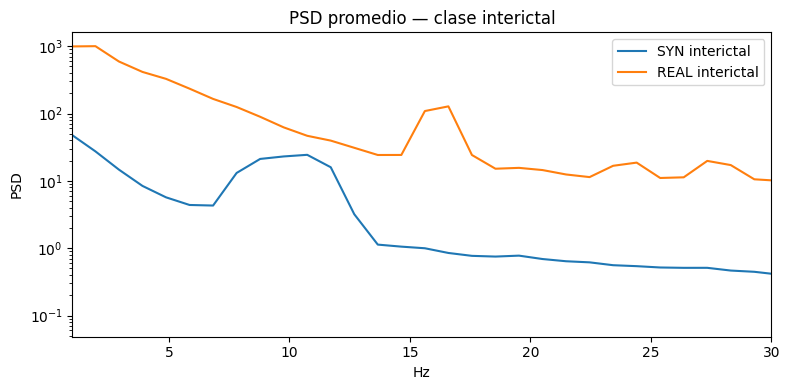

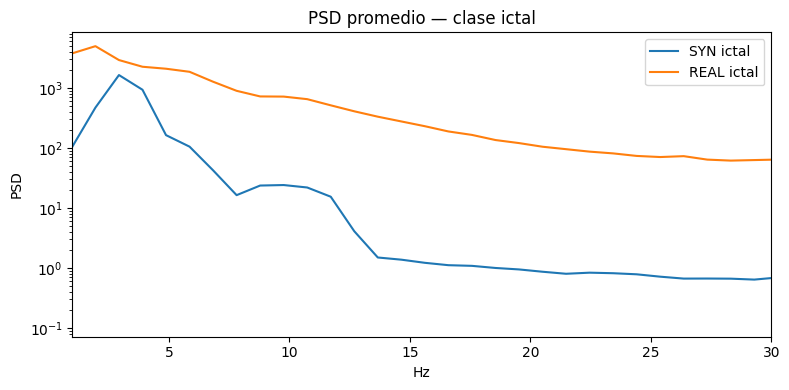

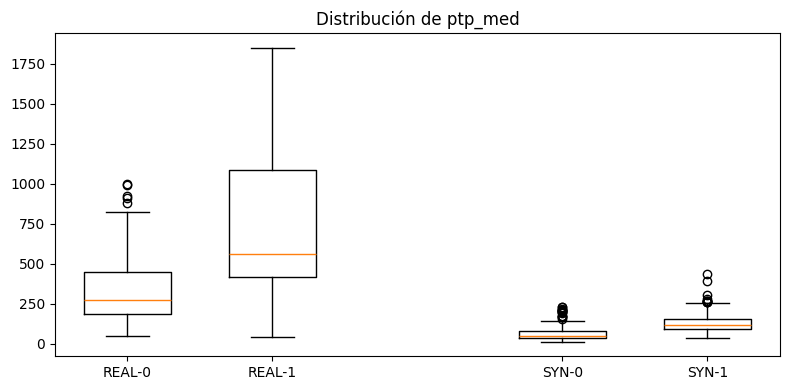

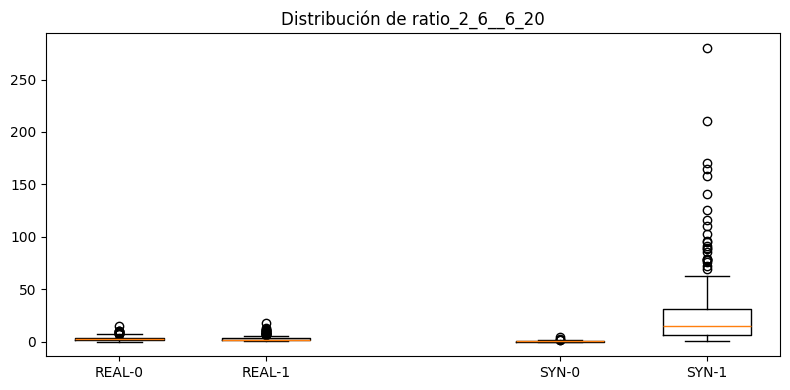

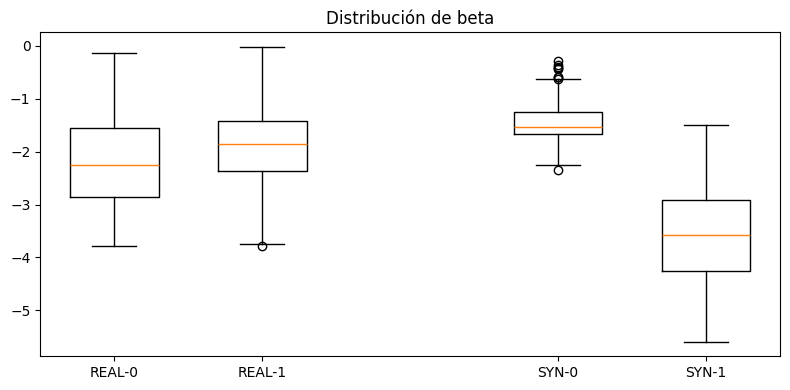

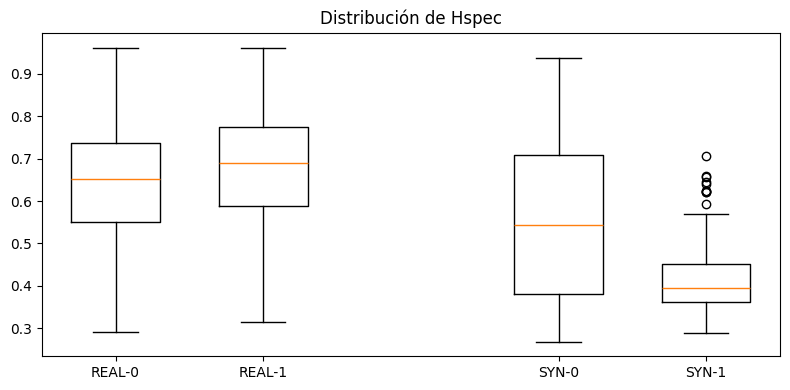

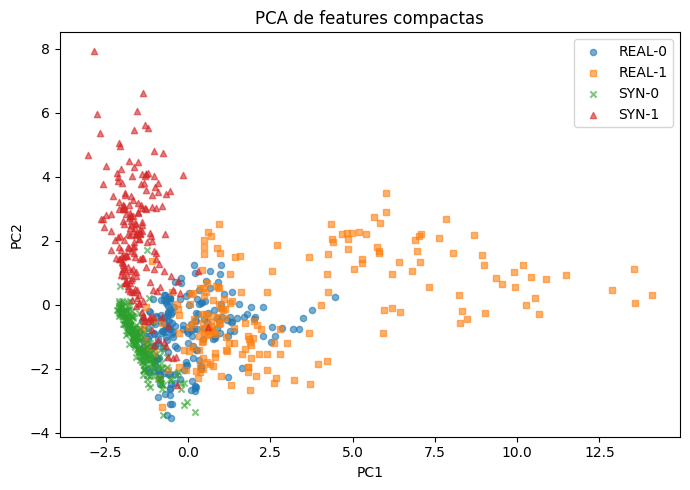

In [14]:
# ============================================================
# BLOQUE 9 — Figuras para paper
# ============================================================

def avg_psd_batch(Xbatch, fs=250):
    P_acc = None
    count = 0

    for i in range(len(Xbatch)):
        x = Xbatch[i]
        nperseg = min(256, x.shape[0])

        for c in range(x.shape[1]):
            f, P = signal.welch(
                x[:, c],
                fs=fs,
                nperseg=nperseg,
                noverlap=nperseg // 2,
                scaling="density"
            )
            P_acc = P if P_acc is None else (P_acc + P)
            count += 1

    return f, P_acc / max(count, 1)

# Subsets chicos para figuras
Xs_fig, ys_fig = sample_balanced_from_splits(
    X_list=[Xtr, Xva, Xte],
    y_list=[ytr, yva, yte],
    ysoft_list=[ytr_soft, yva_soft, yte_soft],
    n_per_class=N_FIG_PER_CLASS,
    seed=SEED + 20,
    pure=False
)
Xr_fig, yr_fig = sample_balanced_array(
    X=Xreal,
    y=yreal,
    n_per_class=min(N_FIG_PER_CLASS, int(np.sum(yreal == 1))),
    seed=SEED + 21,
    pure=False
)

# Figura 1: PSD promedio por clase
for cls, label in [(0, "interictal"), (1, "ictal")]:
    f_s, P_s = avg_psd_batch(Xs_fig[ys_fig == cls], fs=FS)
    f_r, P_r = avg_psd_batch(Xr_fig[yr_fig == cls], fs=FS)

    plt.figure(figsize=(8, 4))
    plt.plot(f_s, P_s, label=f"SYN {label}")
    plt.plot(f_r, P_r, label=f"REAL {label}")
    plt.xlim(1, 30)
    plt.yscale("log")
    plt.xlabel("Hz")
    plt.ylabel("PSD")
    plt.title(f"PSD promedio — clase {label}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"fig_psd_{label}.png"), dpi=200)
    plt.show()

# Figura 2: boxplots de features clave
key_feats = ["ptp_med", "ratio_2_6__6_20", "beta", "Hspec"]
Fsf = extract_feature_matrix(Xs_fig, fs=FS, verbose=False)
Frf = extract_feature_matrix(Xr_fig, fs=FS, verbose=False)

df_plot = []
for feat in key_feats:
    j = FEATURE_NAMES.index(feat)
    for val in Fsf[ys_fig == 0, j]:
        df_plot.append({"feature": feat, "domain": "SYN", "class": "interictal", "value": float(val)})
    for val in Fsf[ys_fig == 1, j]:
        df_plot.append({"feature": feat, "domain": "SYN", "class": "ictal", "value": float(val)})
    for val in Frf[yr_fig == 0, j]:
        df_plot.append({"feature": feat, "domain": "REAL", "class": "interictal", "value": float(val)})
    for val in Frf[yr_fig == 1, j]:
        df_plot.append({"feature": feat, "domain": "REAL", "class": "ictal", "value": float(val)})

df_plot = pd.DataFrame(df_plot)

for feat in key_feats:
    sub = df_plot[df_plot["feature"] == feat]

    plt.figure(figsize=(8, 4))
    positions = [1, 2, 4, 5]
    data = [
        sub[(sub["domain"] == "REAL") & (sub["class"] == "interictal")]["value"].values,
        sub[(sub["domain"] == "REAL") & (sub["class"] == "ictal")]["value"].values,
        sub[(sub["domain"] == "SYN") & (sub["class"] == "interictal")]["value"].values,
        sub[(sub["domain"] == "SYN") & (sub["class"] == "ictal")]["value"].values
    ]
    plt.boxplot(data, positions=positions, widths=0.6)
    plt.xticks(positions, ["REAL-0", "REAL-1", "SYN-0", "SYN-1"])
    plt.title(f"Distribución de {feat}")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"fig_box_{feat}.png"), dpi=200)
    plt.show()

# Figura 3: PCA de features
F_pca = np.vstack([Fsf, Frf])
y_pca = np.concatenate([ys_fig, yr_fig])
d_pca = np.array(["SYN"] * len(Fsf) + ["REAL"] * len(Frf))

Z = StandardScaler().fit_transform(F_pca)
P = PCA(n_components=2, random_state=SEED).fit_transform(Z)

plt.figure(figsize=(7, 5))
for domain, cls, marker in [("REAL", 0, "o"), ("REAL", 1, "s"), ("SYN", 0, "x"), ("SYN", 1, "^")]:
    m = (d_pca == domain) & (y_pca == cls)
    plt.scatter(P[m, 0], P[m, 1], s=20, alpha=0.6, marker=marker, label=f"{domain}-{cls}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA de features compactas")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig_pca_syn_vs_real.png"), dpi=200)
plt.show()

In [15]:
# ============================================================
# BLOQUE 10 — Resumen técnico de evaluación del sintetizador
# ============================================================
# Contexto: el sintetizador no tiene como objetivo replicar EEG real.
# Este bloque resume propiedades observadas en las configuraciones evaluadas.
# Las métricas son descriptivas y no establecen validación clínica,
# superioridad poblacional ni aplicabilidad asistencial.
# ============================================================

# ── 1. Recolección de métricas ────────────────────────────────────────────────

amp_auc    = float(df_leak.loc[df_leak["Modelo"] == "Amp_LogReg",  "ROC_AUC"].iloc[0])
spec_auc   = float(df_leak.loc[df_leak["Modelo"] == "Spec_LogReg", "ROC_AUC"].iloc[0])
all_rf_auc = float(df_leak.loc[df_leak["Modelo"] == "All_RF",      "ROC_AUC"].iloc[0])
smote_mean = globals().get("smote_mean", None)

def get_metric(df_sum, protocol, model, metric):
    row = df_sum[(df_sum["protocol"] == protocol) & (df_sum["model"] == model)]
    if len(row) == 0:
        return float("nan")
    val = row.iloc[0]
    # df_sum is built with .mean().reset_index() — flat columns
    try:
        return float(val[metric])
    except (KeyError, TypeError):
        return float("nan")

# Raw uV summary
util_sum_raw = df_utility.groupby(["protocol", "model"])[["ROC_AUC", "F1"]].mean().reset_index()

r2r_rf_auc_raw  = get_metric(util_sum_raw, "R2R",      "RF", "ROC_AUC")
tstr_rf_auc_raw = get_metric(util_sum_raw, "TSTR",     "RF", "ROC_AUC")
trts_rf_auc_raw = get_metric(util_sum_raw, "TRTS",     "RF", "ROC_AUC")
aug_rf_auc_raw  = get_metric(util_sum_raw, "R+S_to_R", "RF", "ROC_AUC")

# Z-score summary
util_sum_z = df_utility_z.groupby(["protocol", "model"])[["ROC_AUC", "F1"]].mean().reset_index()

r2r_rf_auc_z  = get_metric(util_sum_z, "R2R",      "RF", "ROC_AUC")
tstr_rf_auc_z = get_metric(util_sum_z, "TSTR",     "RF", "ROC_AUC")
trts_rf_auc_z = get_metric(util_sum_z, "TRTS",     "RF", "ROC_AUC")
aug_rf_auc_z  = get_metric(util_sum_z, "R+S_to_R", "RF", "ROC_AUC")

# Use z-score as the primary evaluated variant to reduce the influence of absolute scale
r2r_rf_auc  = r2r_rf_auc_z
tstr_rf_auc = tstr_rf_auc_z
trts_rf_auc = trts_rf_auc_z
aug_rf_auc  = aug_rf_auc_z

fid_gap_mean  = float(df_fidelity["median_gap_over_real_iqr"].mean())
div_ratio_mem = float(df_div["ratio_synreal_over_realreal"].mean())
div_ratio_div = float(df_div["ratio_synsyn_over_realreal"].mean())
frac_close    = float(df_div["fraction_syn_suspiciously_close_to_real"].mean())

# ── 2. Estructura del resumen ─────────────────────────────────────────────────

summary = {
    # Separabilidad interna — sobre el dataset sintético
    "separability_amplitude_only_auroc":    amp_auc,
    "separability_spectral_features_auroc": spec_auc,
    "separability_all_features_auroc":      all_rf_auc,

    # Utilidad de transferencia — raw_uV (para referencia)
    # Nota: las features raw_uV incluyen diferencias de amplitud entre
    # dominios SYN (µV sintéticos) y REAL (CHB-MIT). Esta variante se
    # conserva como referencia descriptiva de la influencia de escala absoluta.
    "transfer_real_to_real_auroc_raw_uV":       r2r_rf_auc_raw,
    "transfer_synthetic_to_real_auroc_raw_uV":  tstr_rf_auc_raw,
    "transfer_real_to_synthetic_auroc_raw_uV":  trts_rf_auc_raw,
    "transfer_augmented_to_real_auroc_raw_uV":  aug_rf_auc_raw,

    # Utilidad de transferencia — z-score (variante primaria evaluada)
    # z-score por canal por ventana antes de extraer features.
    # Se evalúa para reducir la influencia de escala absoluta entre dominios;
    # no elimina todos los posibles sesgos ni identifica mecanismos aprendidos.
    "transfer_real_to_real_auroc":              r2r_rf_auc_z,
    "transfer_synthetic_to_real_auroc":         tstr_rf_auc_z,
    "transfer_real_to_synthetic_auroc":         trts_rf_auc_z,
    "transfer_augmented_to_real_auroc":         aug_rf_auc_z,

    # Fidelidad estadística
    "fidelity_median_displacement_over_iqr":    fid_gap_mean,

    # Evaluación de cercanía o memorización en espacio de características y diversidad
    "privacy_synthetic_to_real_distance_ratio": div_ratio_mem,
    "diversity_internal_vs_real_ratio":         div_ratio_div,
    "privacy_fraction_memorized":               frac_close,
}

# ── 3. Hallazgos contextualizados ─────────────────────────────────────────────

findings = []

# Separabilidad de amplitud
if amp_auc >= 0.95:
    findings.append(
        "En el conjunto evaluado, la amplitud absoluta distingue clases con AUROC={:.3f}. "
        "Las features raw_uV muestran diferencias de amplitud entre clases y dominios. "
        "El benchmark primario evalúa z-score por ventana para reducir la influencia "
        "de escala absoluta, sin eliminar todos los posibles sesgos.".format(amp_auc)
    )
elif amp_auc >= 0.85:
    findings.append(
        "En el conjunto evaluado, la amplitud contribuye a la separabilidad (AUROC={:.3f}). "
        "Se evalúa z-score para reducir la influencia de escala absoluta, "
        "sin eliminar todos los posibles sesgos.".format(amp_auc)
    )
else:
    findings.append(
        "En el conjunto evaluado, la amplitud sola presenta AUROC={:.3f}.".format(amp_auc)
    )

# Firma espectral
if spec_auc >= 0.90:
    findings.append(
        "En los datos evaluados, las características espectrales presentan AUROC={:.3f} "
        "y separabilidad asociada a la banda 2-6 Hz. Este resultado no constituye "
        "validación clínica ni confirmación de morfología ictal.".format(spec_auc)
    )
else:
    findings.append(
        "Separabilidad espectral observada (AUROC={:.3f}) en las características "
        "evaluadas, sin validación clínica de morfología ictal.".format(spec_auc)
    )

# Impacto del z-score en TSTR
tstr_delta = tstr_rf_auc_z - tstr_rf_auc_raw
findings.append(
    "Comparación TSTR raw_uV vs z-score: AUROC_raw={:.3f}, AUROC_z={:.3f} "
    "(delta={:+.3f}). {}".format(
        tstr_rf_auc_raw, tstr_rf_auc_z, tstr_delta,
        "En las particiones evaluadas, la variante z-score muestra mayor AUROC TSTR que raw_uV; "
        "fue evaluada para reducir la influencia de escala absoluta sin eliminar todos los posibles sesgos." if tstr_delta > 0 else
        "En las particiones evaluadas, la variante z-score no muestra mayor AUROC TSTR que raw_uV. "
        "La variabilidad inter-sujeto puede contribuir al resultado observado."
    )
)

# Transferencia SYN→REAL (métrica principal con z-score)
tstr_gap = r2r_rf_auc_z - tstr_rf_auc_z
if tstr_rf_auc_z >= 0.80:
    findings.append(
        "Resultado TSTR observado (z-score): un modelo entrenado exclusivamente en "
        "datos sintéticos presenta AUROC={:.3f} en datos reales (CHB-MIT), con "
        "una diferencia de {:.3f} respecto a R2R (AUROC={:.3f}). Este resultado "
        "se limita a las particiones evaluadas y no establece superioridad poblacional "
        "ni aplicabilidad asistencial.".format(
            tstr_rf_auc_z, tstr_gap, r2r_rf_auc_z)
    )
elif tstr_rf_auc_z >= 0.65:
    findings.append(
        "Resultado TSTR observado con z-score: AUROC={:.3f} (diferencia={:.3f} vs "
        "R2R={:.3f}) en las particiones evaluadas. La variabilidad entre particiones "
        "se reporta descriptivamente y no establece utilidad morfológica clínica.".format(
            tstr_rf_auc_z, tstr_gap, r2r_rf_auc_z)
    )
else:
        findings.append(
        "Resultado TSTR observado con z-score: AUROC={:.3f} en las particiones evaluadas. "
        "La variabilidad inter-sujeto puede contribuir al desempeño observado; "
        "este resultado no permite atribuir causalidad ni validar morfología ictal.".format(tstr_rf_auc_z)
    )

# Augmentación
aug_gap = aug_rf_auc_z - r2r_rf_auc_z
if aug_rf_auc_z >= r2r_rf_auc_z - 0.005:
    findings.append(
        "En las particiones evaluadas, real+sintético presenta AUROC_z={:.3f} "
        "frente a R2R_z={:.3f}. La comparación es descriptiva y no demuestra "
        "ausencia de sesgo introducido por los datos sintéticos.".format(
            aug_rf_auc_z, r2r_rf_auc_z)
    )
else:
    findings.append(
        "En las particiones evaluadas, real+sintético presenta AUROC_z={:.3f} "
        "frente a R2R_z={:.3f} (delta={:.3f}). Esta comparación descriptiva "
        "no identifica el mecanismo de la diferencia observada.".format(aug_rf_auc_z, r2r_rf_auc_z, aug_gap)
    )

# Comparación con baseline SMOTE
if smote_mean is not None:
    smote_delta = tstr_rf_auc_z - smote_mean
    if smote_delta >= -0.05:
        findings.append(
            "Baseline SMOTE→R: AUROC={:.3f}. TSTR presenta delta={:+.3f} frente "
            "a SMOTE en las particiones evaluadas. Esta comparación es descriptiva "
            "y no valida morfología ictal ni establece ventaja poblacional.".format(
                smote_mean, smote_delta)
        )
    else:
        findings.append(
            "Baseline SMOTE→R: AUROC={:.3f} frente a TSTR={:.3f} (delta={:+.3f}) "
            "en las particiones evaluadas. La comparación se reporta descriptivamente "
            "y no permite inferir ventajas generales entre métodos.".format(
                smote_mean, tstr_rf_auc_z, smote_delta)
        )

# Evaluación de cercanía o memorización en espacio de características
if frac_close <= 0.01:
    findings.append(
        "Evaluación de cercanía en espacio de características: fracción clasificada "
        "como cercana={:.1%}. Este análisis no garantiza privacidad ni descarta "
        "memorización en la señal cruda.".format(
            frac_close)
    )
else:
    findings.append(
        "Evaluación de cercanía en espacio de características: fracción clasificada "
        "como cercana={:.1%}. Este análisis descriptivo no garantiza privacidad "
        "sobre la señal cruda.".format(frac_close)
    )

# Diversidad observada en espacio de características
if div_ratio_div >= 0.50:
    findings.append(
        "Diversidad sintética observada en espacio de características: ratio={:.3f} "
        "respecto a la variabilidad real. Este resultado no demuestra prevención "
        "de sobreajuste.".format(div_ratio_div)
    )
else:
    findings.append(
        "Diversidad sintética observada en espacio de características: ratio={:.3f} "
        "respecto a la variabilidad real. Los datos evaluados muestran menor "
        "diversidad relativa, sin atribuir un mecanismo causal.".format(div_ratio_div)
    )

# Fidelidad estadística
if fid_gap_mean <= 1.00:
    findings.append(
        "Desplazamiento medio observado={:.2f} IQR en las características "
        "evaluadas. Esta comparación se reporta descriptivamente.".format(fid_gap_mean)
    )
elif fid_gap_mean <= 1.50:
    findings.append(
        "Desplazamiento medio observado={:.2f} IQR en las características evaluadas. "
        "Se observan diferencias entre datos sintéticos y reales; este análisis "
        "no confirma morfología ictal ni determina utilidad general.".format(fid_gap_mean)
    )
else:
    findings.append(
        "Desplazamiento observado={:.2f} IQR en las características evaluadas. "
        "La diferencia se reporta como limitación descriptiva, sin validar "
        "morfología ictal.".format(fid_gap_mean)
    )

summary["findings"] = findings

# ── 4. Output ─────────────────────────────────────────────────────────────────

print(json.dumps(summary, indent=2, ensure_ascii=False))

with open(os.path.join(OUT_DIR, "05_final_summary.json"), "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

pd.DataFrame({"finding": findings}).to_csv(
    os.path.join(OUT_DIR, "05_final_verdict_lines.csv"),
    index=False
)

print("\n" + "="*65)
print(" SINTESIS EJECUTIVA (z-score = variante primaria evaluada)")
print("="*65)
print(f"  TSTR raw_uV (referencia)                   : AUROC = {tstr_rf_auc_raw:.3f}")
print(f"  TSTR z-score (metrica principal)           : AUROC = {tstr_rf_auc_z:.3f}")
print(f"  Diferencia z-score vs raw_uV               : delta = {tstr_delta:+.3f}")
print(f"  Baseline REAL->REAL (z-score)              : AUROC = {r2r_rf_auc_z:.3f}")
print(f"  Brecha de transferencia (z-score)          : delta = {tstr_gap:.3f}")
print(f"  Transferencia REAL->SYN (z-score)          : AUROC = {trts_rf_auc_z:.3f}")
print(f"  Fraccion cercana en espacio de features    : {frac_close:.1%}")
print(f"  Diversidad inter-paciente (vs real)        : {div_ratio_div:.3f}")
print(f"  Fidelidad estadistica (gap/IQR)            : {fid_gap_mean:.2f}")
print("="*65)

if tstr_rf_auc_z >= 0.80 and frac_close <= 0.01:
    print("  CONCLUSION DESCRIPTIVA: se observo rendimiento TSTR en las particiones evaluadas.")
    print("  La cercania en features no garantiza privacidad sobre la senal cruda.")
    print("  No se extrapola este resultado a uso asistencial.")
elif tstr_rf_auc_z >= 0.65:
    print("  CONCLUSION DESCRIPTIVA: se reporta TSTR z-score en las particiones evaluadas.")
    print("  La variabilidad inter-sujeto puede contribuir a la varianza observada del TSTR.")
    print("  Las variantes raw_uV y z-score se presentan como analisis descriptivos.")
else:
    print("  CONCLUSION DESCRIPTIVA: el TSTR observado presenta variabilidad entre particiones por sujeto.")
    print("  La separabilidad espectral observada (spec AUC={:.3f}) no valida morfologia ictal.".format(spec_auc))
    print("  TSTR z-score={:.3f}; resultado limitado a las particiones evaluadas.".format(tstr_rf_auc_z))
print("="*65)


{
  "separability_amplitude_only_auroc": 0.9946835555555557,
  "separability_spectral_features_auroc": 0.9994799999999999,
  "separability_all_features_auroc": 0.9994824444444445,
  "transfer_real_to_real_auroc_raw_uV": 0.6661202594426417,
  "transfer_synthetic_to_real_auroc_raw_uV": 0.6294781424503827,
  "transfer_real_to_synthetic_auroc_raw_uV": 0.6294789333333333,
  "transfer_augmented_to_real_auroc_raw_uV": 0.6378331021358125,
  "transfer_real_to_real_auroc": 0.4662052858444121,
  "transfer_synthetic_to_real_auroc": 0.6132096358332443,
  "transfer_real_to_synthetic_auroc": 0.5661900888888889,
  "transfer_augmented_to_real_auroc": 0.541728963735004,
  "fidelity_median_displacement_over_iqr": 1.0448120850505827,
  "privacy_synthetic_to_real_distance_ratio": 2.4278316497802734,
  "diversity_internal_vs_real_ratio": 0.5685593485832214,
  "privacy_fraction_memorized": 0.008,
  "findings": [
    "En el conjunto evaluado, la amplitud absoluta distingue clases con AUROC=0.995. Las features